In this notebook, we use TACTiCS to match cell types from human and mouse using ProtBERT embeddings.

In [1]:
import sys
from pathlib import Path
def sys_path_show():
    print(*sys.path,sep='\n')
def sys_path_append(p):
    p = Path(p)
    assert p.exists()
    p = str(p)
    None if p in sys.path else sys.path.append(p)

sys_path_append(Path("~/link").expanduser())
sys_path_append(Path("~/link/temp/241120_other_model/learn_TACTiCS").expanduser())

In [2]:
import utils as ut
from utils.general import *

In [3]:
import TACTiCS
utils = TACTiCS.utils
TACTiCS = TACTiCS.tactics.TACTiCS
# from genes import embed_proteins, calc_dist
import torch
torch.cuda.is_available()

False


> 追加文件 `TACTiCS/__init__.py`

TACTiCS的utils 和 我的utils重名了....可恶

```python
import TACTiCS.utils as utils
import TACTiCS.tactics
```
> 修改文件 `TACTiCS/tactics.py`

```python
# import utils # TACTiCS文件夹被视为包了, 这样时外部的utils 即我的utils
import TACTiCS.utils as utils
```

|file|function|note||
|:-|:-|:-|:-|
|tactics|TACTiCS.train|gpu不可用, 不使用cuda||
|tactics|TACTiCS.norm_adata|版本适用写法|输出太多版本更新提示,浏览器无法承受|
|utils|utilsget_batch|版本适用写法||

In [4]:
import torch
import torch.nn as nn
import tqdm

import numpy as np
import torch
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy
# pd.set_option('future.no_silent_downcasting', True)

def customize_TACTiCS_train(self, n_epochs=200, batch_size=5000):
    # 不使用 .cuda()
    
    self.model.train()
    # self.model.cuda()

    weight_A = torch.Tensor([1 for _ in range(self.n_classes_A)])#.cuda()
    weight_B = torch.Tensor([1 for _ in range(self.n_classes_B)])#.cuda()
    loss_fn_A = nn.CrossEntropyLoss(label_smoothing=0.1, weight=weight_A)
    loss_fn_B = nn.CrossEntropyLoss(label_smoothing=0.1, weight=weight_B)

    # return utils.get_batch(self.adata_A, self.dict_A["column"], 0)
    for epoch in tqdm.tqdm(range(n_epochs)):
        for batch in range(30):
            self.optimizer.zero_grad()
            
            x_A, y_A = utils.get_batch(self.adata_A, self.dict_A["column"], batch_size)
            x_B, y_B = utils.get_batch(self.adata_B, self.dict_B["column"], batch_size)

            # x_A, y_A = x_A.cuda(), y_A.cuda()
            # x_B, y_B = x_B.cuda(), y_B.cuda()

            preds_A, preds_B, closest_dist = self.model(x_A, x_B)

            preds_top_A = preds_A.argmax(dim=1)
            preds_top_B = preds_B.argmax(dim=1)

            loss = loss_fn_A(preds_A, y_A) + loss_fn_B(preds_B, y_B) + closest_dist
            loss.backward()
            nn.utils.clip_grad_value_(self.model.parameters(), clip_value=0.5)
            self.optimizer.step()

        utils.update_weights_focal(y_A, preds_top_A, self.n_classes_A, weight_A)
        utils.update_weights_focal(y_B, preds_top_B, self.n_classes_B, weight_B)

TACTiCS.train = customize_TACTiCS_train
del customize_TACTiCS_train

def customize_TACTiCS_norm_adata(self, adata: ad.AnnData, proteins):
    # Normalize per cell and with log
    sc.pp.normalize_total(adata, target_sum=10000)
    sc.pp.log1p(adata)
    del adata.uns["log1p"]

    # Filter matrix to genes with protein sequences
    adata = adata[:, adata.var_names.isin(proteins)]

    # Calculate highly variable genes
    # 版本适用写法
    # scanpy.pp.highly_variable_genes(adata, 2000)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    
    adata.var.drop(["means", "dispersions", "dispersions_norm"], axis="columns", inplace=True)
    adata.uns["hvg"] = {}
    # del adata.uns["hvg"]
    return adata
TACTiCS.norm_adata = customize_TACTiCS_norm_adata
del customize_TACTiCS_norm_adata


def customize_TACTiCS_get_directional_conf(self, include_counts=False):
    # 版本不适用 sklearn.metrics.confusion_matrix
    from sklearn.metrics import confusion_matrix
    
    
    labels_A = set(self.adata_A.obs[self.dict_A["column"]].cat.categories)
    labels_B = set(self.adata_B.obs[self.dict_B["column"]].cat.categories)
    labels = np.array(sorted(list(labels_A.union(labels_B))))
    idx_A = [i for i in range(len(labels)) if labels[i] in set(labels_A)]
    idx_B = [i for i in range(len(labels)) if labels[i] in set(labels_B)]
    labels_A = labels[idx_A]
    labels_B = labels[idx_B]

    y_A = self.adata_A.obs[self.dict_A["column"]].values
    transfer_A = self.adata_A.obs[self.dict_B["name"]].values
    y_B = self.adata_B.obs[self.dict_B["column"]].values
    transfer_B = self.adata_B.obs[self.dict_A["name"]].values

    if include_counts:
        labels_A = [f"{x} ({self.adata_A.obs[self.dict_A['column']].value_counts().loc[x]})" for x in labels_A]
        labels_B = [f"{x} ({self.adata_B.obs[self.dict_B['column']].value_counts().loc[x]})" for x in labels_B]

    conf_matrix_A = confusion_matrix(y_A, transfer_A, normalize="true", labels=labels)
    conf_matrix_A = conf_matrix_A[idx_A, :]
    conf_matrix_A = conf_matrix_A[:, idx_B]

    conf_matrix_B = confusion_matrix(y_B, transfer_B, normalize="true", labels=labels)
    conf_matrix_B = conf_matrix_B[idx_B, :]
    conf_matrix_B = conf_matrix_B[:, idx_A]

    return labels_A, labels_B, conf_matrix_A, conf_matrix_B

TACTiCS.get_directional_conf = customize_TACTiCS_get_directional_conf
del customize_TACTiCS_get_directional_conf

def customize_utils_get_batch(adata, column, n):
    total = len(adata)
    if n == total:
        x = torch.Tensor(adata.X)
        y = adata.obs[column].cat.codes
    else:
        weights = 1 / adata.obs[column].value_counts()
        cts = adata.obs[column]
        # 版本适用写法
        # weights = np.array(pd.Series.replace(cts, weights).values)
        weights = np.array((weights[cts.astype(str)].values))
        # return cts,weights
        weights = weights / sum(weights)
        idx = sorted(np.random.choice(total, n, replace=True, p=weights))

        x = torch.Tensor(adata[idx, :].X)
        # 版本适用写法
        # y = adata.obs[column].cat.codes[idx]
        y = adata.obs[column].cat.codes.iloc[idx]

    # 版本适用写法
    y = torch.Tensor(y.values).to(torch.long)
    return x, y
utils.get_batch = customize_utils_get_batch
del customize_utils_get_batch

### Loading data
We define a dictionary for each species containing the species `name`, path to the protein `sequences`, path to the protein `embeddings`, path to the raw `counts`, path to map from protein names to `genes`, and the `column` name that should be used as cell type. Here, we use a 50k subset from the Allen Brain Data, which can be downloaded from [Zenodo](https://doi.org/10.5281/zenodo.7582460).

In [5]:
human = dict(name="Human",
             sequences="tutorial/human_proteins.fasta",
             embeddings="tutorial/human_proteins_embeddings.pkl",
             counts="tutorial/human.h5ad",
             genes="tutorial/human_names.pkl",
             column="Subclass")

mouse = dict(name="Mouse",
             sequences="tutorial/mouse_proteins.fasta",
             embeddings="tutorial/mouse_proteins_embeddings.pkl",
             counts="tutorial/mouse.h5ad",
             genes="tutorial/mouse_names.pkl",
             column="Subclass")

### Creating ProtBERT embeddings
`embed_proteins` creates a ProtBERT embedding for every protein sequence in `sequences`. By default, the embeddings are saved in `*_embeddings.pkl`. Because this is a time expensive step, we also provide the calculated embeddings.

In [ ]:
# embed_proteins(human)
# embed_proteins(mouse)

### Calculating initial gene matches
`calc_dist` calculates and saves the protein embedding distances using the cosine distance in a sparse format. Alternatively, `calc_dist_blast` can be used to convert BLAST distances to a similar format.

In [ ]:
# calc_dist(human, mouse, "tutorial/human_mouse_dist.pkl")

### Training TACTiCS
`TACTiCS` initializes the model for a comparison between two species, at a specific resolution (in this case Subclass). The two scRNA-seq datasets are first normalized after which the highly variable genes are calculated separately per species. The gene distances are used to create gene matches, which are filtered using the highly variable genes. Finally, the datasets are subset to the relevant genes only.

We use `genes` to map from the protein names to the gene names. Mappings are available for human, mouse, marmoset and rat. For other species, please rename the proteins in `*_dist.pkl` using the gene names.

In [ ]:
print(*human.keys(),sep='\n')

In [ ]:
model = TACTiCS(human, mouse, "tutorial/human_mouse_dist.pkl")

`train` trains the model for 200 epochs. In every epoch, batches of 5000 cells are sampled from the dataset. To account for smaller cell types, a similar amount of cells is sampled from each cell type. After the model is trained, `transfer` transfers the cell types and creates the cell embeddings.

In [ ]:
model.train(n_epochs=50)

In [ ]:
model.transfer()

### Saving and loading model
The dictionaries, trained weights and preprocessed/subset scRNA-seq datasets can be stored using `save` and providing a directory.

In [ ]:
Path("tutorial/Subclass/human_mouse").mkdir(parents=True,exist_ok=True)
model.save("tutorial/Subclass/human_mouse")

The saved model can be loaded by providing the directory when creating a `TACTiCS` object.

In [6]:
model = TACTiCS(folder="tutorial/Subclass/human_mouse")

/public/workspace/licanchengup/download/temp/241120_other_model/learn_TACTiCS/TACTiCS/tactics.py:279: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dic

### Plotting results
`plot_matches` plots the cell type matches resulting from `transfer`.

`plot_embeddings` creates two UMAP plots using `scanpy.pl.umap` from the cell embeddings that were calculated in `transfer`.

[out][plot] TACTiCS_1.pdf 
	in .


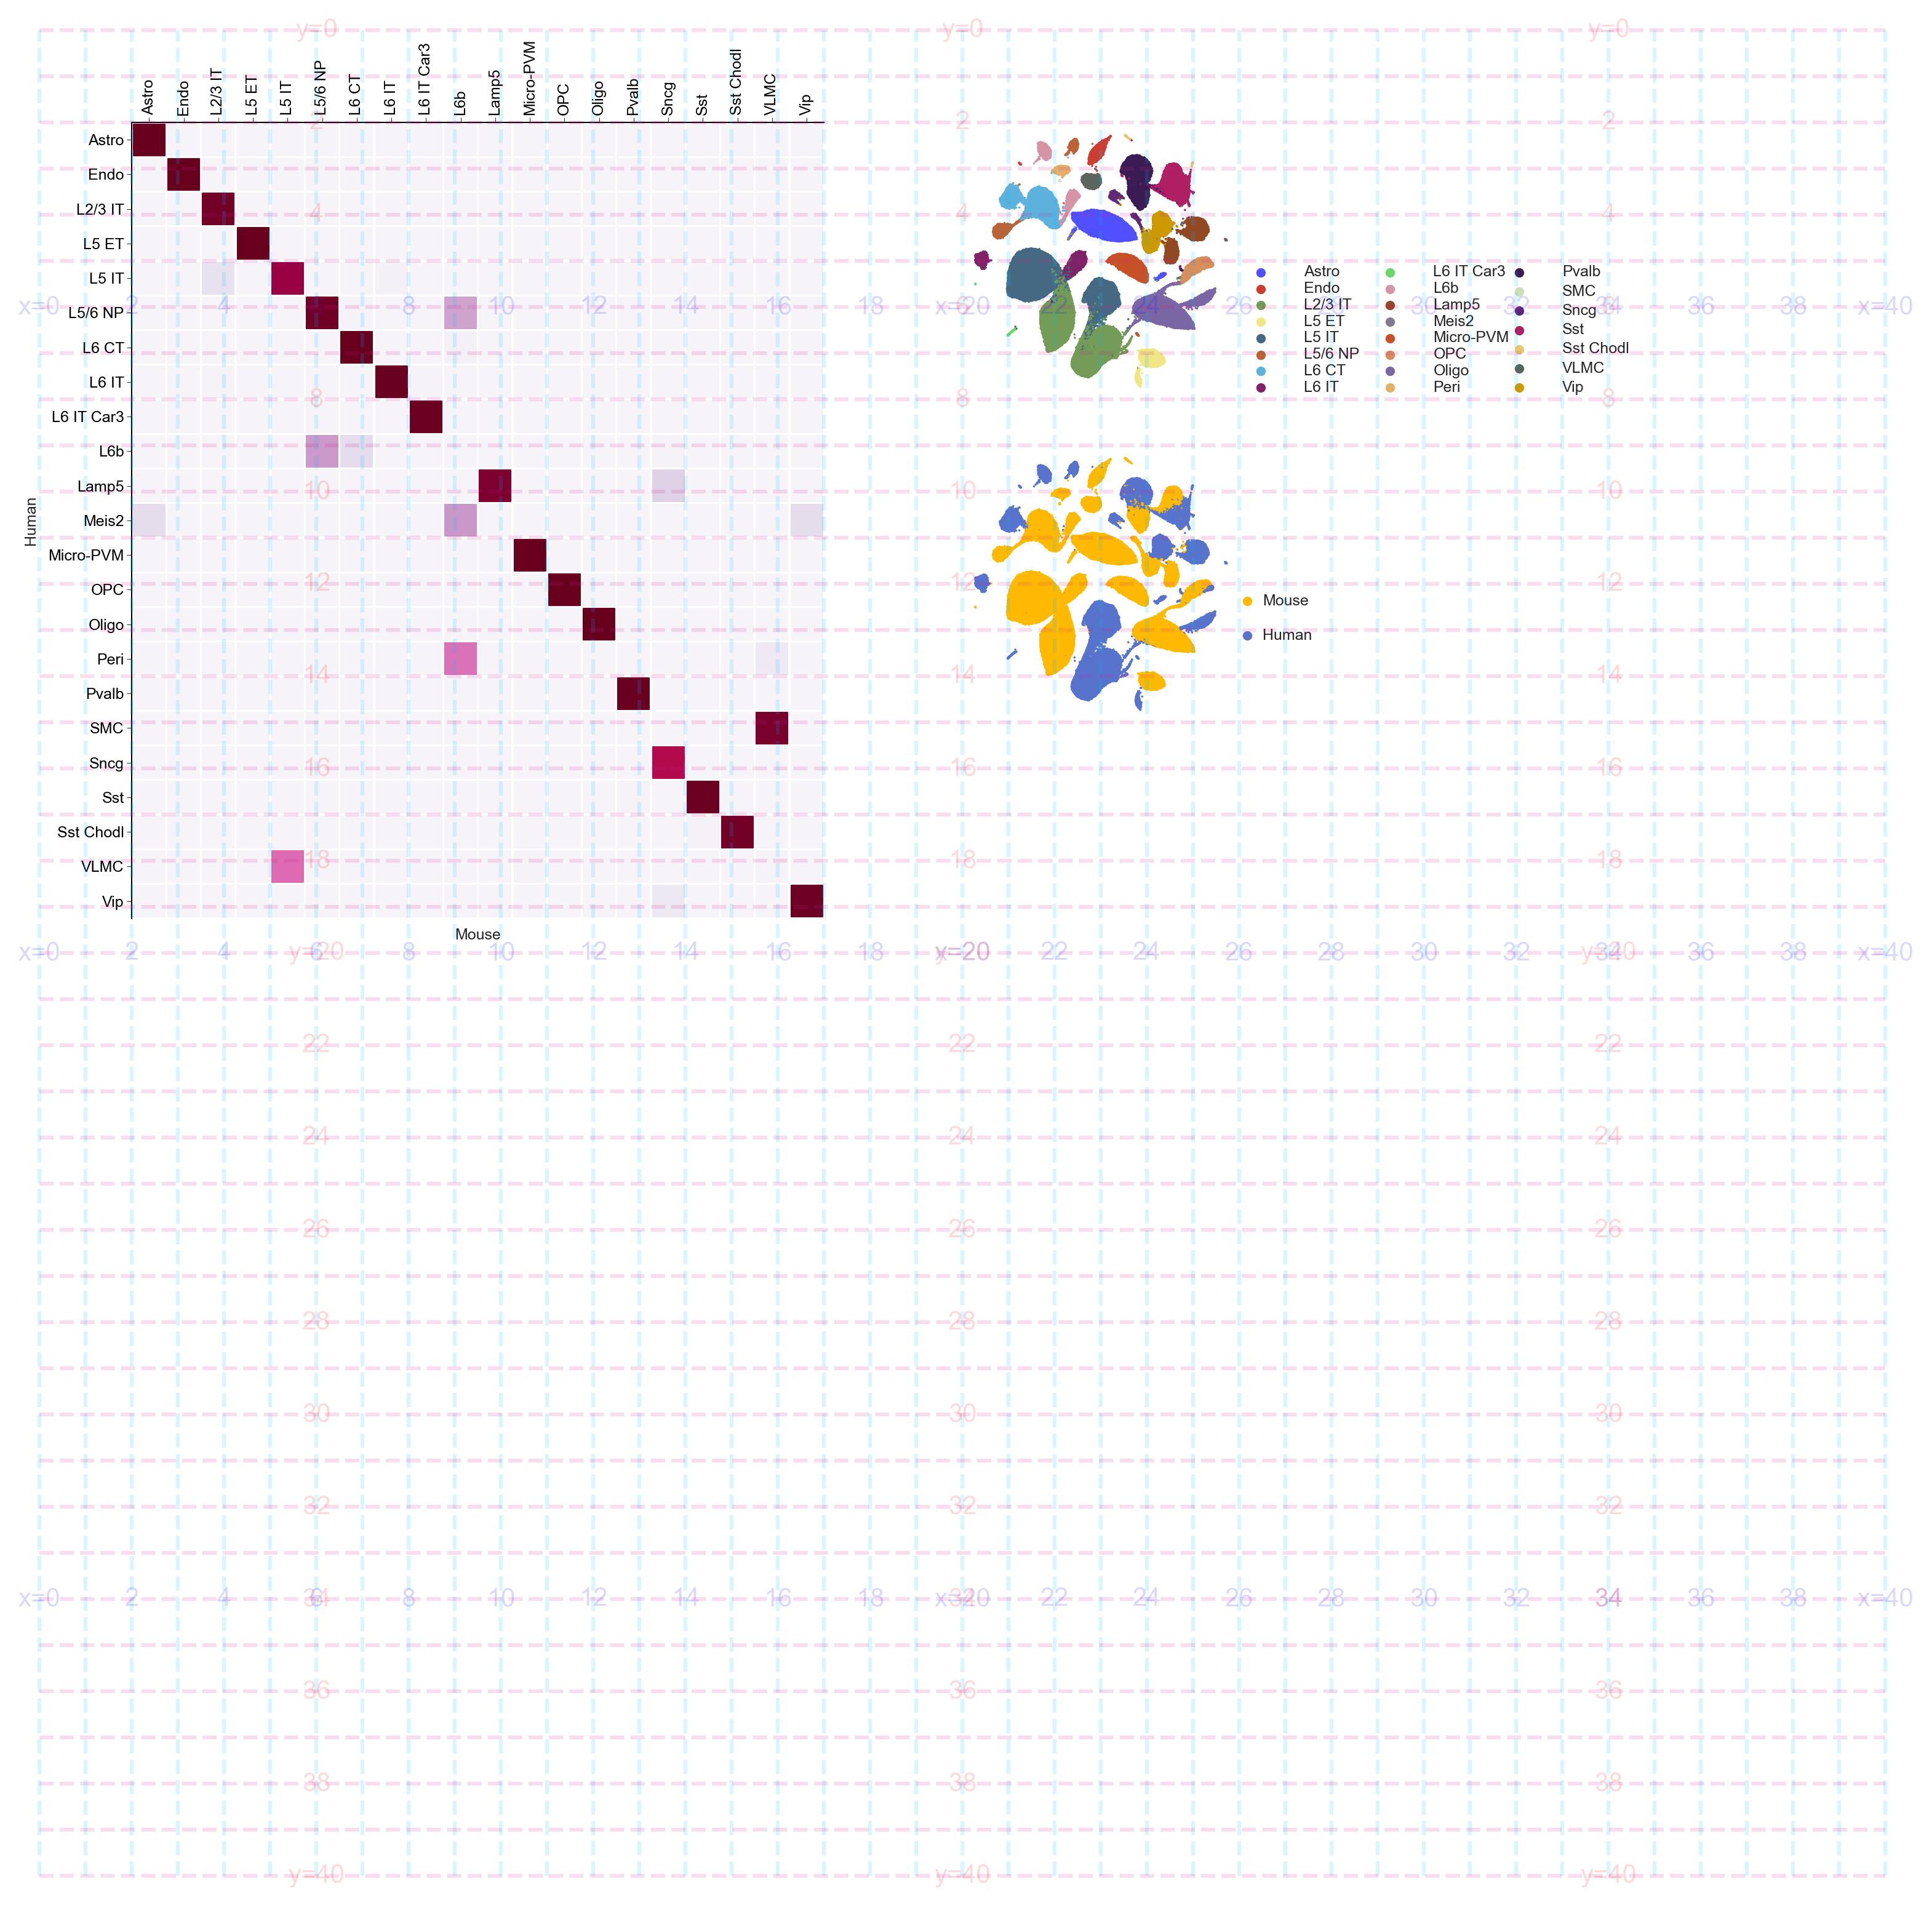

In [7]:
pl = ut.pl

plt.close('all')
a4p = pl.figure.DrawingBoard(nrows=40,ncols=40)

y = 2
with Block('plot match',context=dict(x=2,y = y)) as context:
    labels_A, labels_B, matrix = model.get_avg_conf(False)
    df_plot = pd.DataFrame(matrix,index=labels_A,columns=labels_B)
    factor_shape = .75
    factor_size = 150
    df_size = pd.DataFrame(np.ones(df_plot.shape)*factor_size,
                           index=df_plot.index,columns=df_plot.columns)
    shape = np.array(df_size.shape)*factor_shape
    ax = a4p.add_ax(context.x,context.y,*shape,rc=pl.rc_frame_lt)
    pl.bubble(df_size,ax,df_plot,fontdict_xtick=dict(rotation=90)
              ,marker='s',cmap='PuRd')
    ax.set_xlabel('Mouse')
    ax.set_ylabel('Human')
    del labels_A,labels_B,matrix
    del df_plot,df_size,factor_shape,factor_size,ax

with Block('plot umap',context=dict(x=20,y = y)) as context:
    if Path('tutorial/Subclass/human_mouse/adt.h5ad').exists():
        adt = sc.read_h5ad('tutorial/Subclass/human_mouse/adt.h5ad')
    else:
        adt = sc.AnnData(np.concatenate([model.adata_A.obsm["emb"],
                                         model.adata_B.obsm["emb"]], axis=0))
        adt.obs["specie"] = [model.dict_A["name"] for _ in range(len(model.adata_A))] + \
                               [model.dict_B["name"] for _ in range(len(model.adata_B))]
        adt.obs["cell type"] = np.concatenate([model.adata_A.obs[model.dict_A["column"]].to_numpy(),
                                 model.adata_B.obs[model.dict_B["column"]].to_numpy()], axis=0)
        sc.pp.neighbors(adt, n_neighbors=30)
        sc.tl.umap(adt)
        adt.write_h5ad('tutorial/Subclass/human_mouse/adt.h5ad')
    key = 'cell type'
    adt.obs[key] = adt.obs[key].astype(str)
    ax = a4p.add_ax(context.x,context.y,6,6,rc=pl.rc_frame)
    cmap = pl.cmap.ggsci.get_cmap('IGV',np.unique(adt.obs[key]))
    ut.sc.pl.umap(adt,key,cmap=cmap,ax=ax,size=.5)
    ax.set_rasterized(True)
    a4p.area_update(context.x+6,context.y+2,1,3,2.8,5)
    for keys,ax in zip(np.array_split(list(cmap.keys()),3),
                   a4p.area_yield_ax(rc=pl.rc_blank)):
        pl.cmap.show(subset_dict(cmap,keys),ax=ax)

    context.y += 7
    key = 'specie'
    adt.obs[key] = adt.obs[key].astype(str)
    ax = a4p.add_ax(context.x,context.y,6,6,rc=pl.rc_frame)
    cmap = {
        'Mouse':'#FFB900',
        'Human':'#5773CC'
    }
    ut.sc.pl.umap(adt,key,cmap=cmap,ax=ax,size=.5)
    ax.set_rasterized(True)
    
    ax = a4p.add_ax(context.x+6,context.y+3,1,1.5,rc=pl.rc_blank)
    pl.cmap.show(cmap,ax=ax)

    del adt,key,ax,cmap,keys

pl.tl_savefig(a4p.fig,'TACTiCS_1.pdf')
a4p.add_grid()

The average diagonal score (ADS) and recall used to score the quality of the cell type matches can be calculated using `get_ADS` and `get_recall`.

In [ ]:
model.get_ADS()
model.get_recall()